In [ ]:
import math
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

from helper_functions import load_signal_data

warnings.simplefilter("ignore", pd.errors.DtypeWarning)

In [3]:
# Load raw data
dfs_raw = load_signal_data(search_folder="RawMeasurements/2024-06-01_2024-10-31/G2_relevant")

/home/henrik/Documents/Thesis_master/EDA/helper_functions.py:85: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/home/henrik/Documents/Thesis_master/EDA/helper_functions.py:85: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/home/henrik/Documents/Thesis_master/EDA/helper_functions.py:85: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


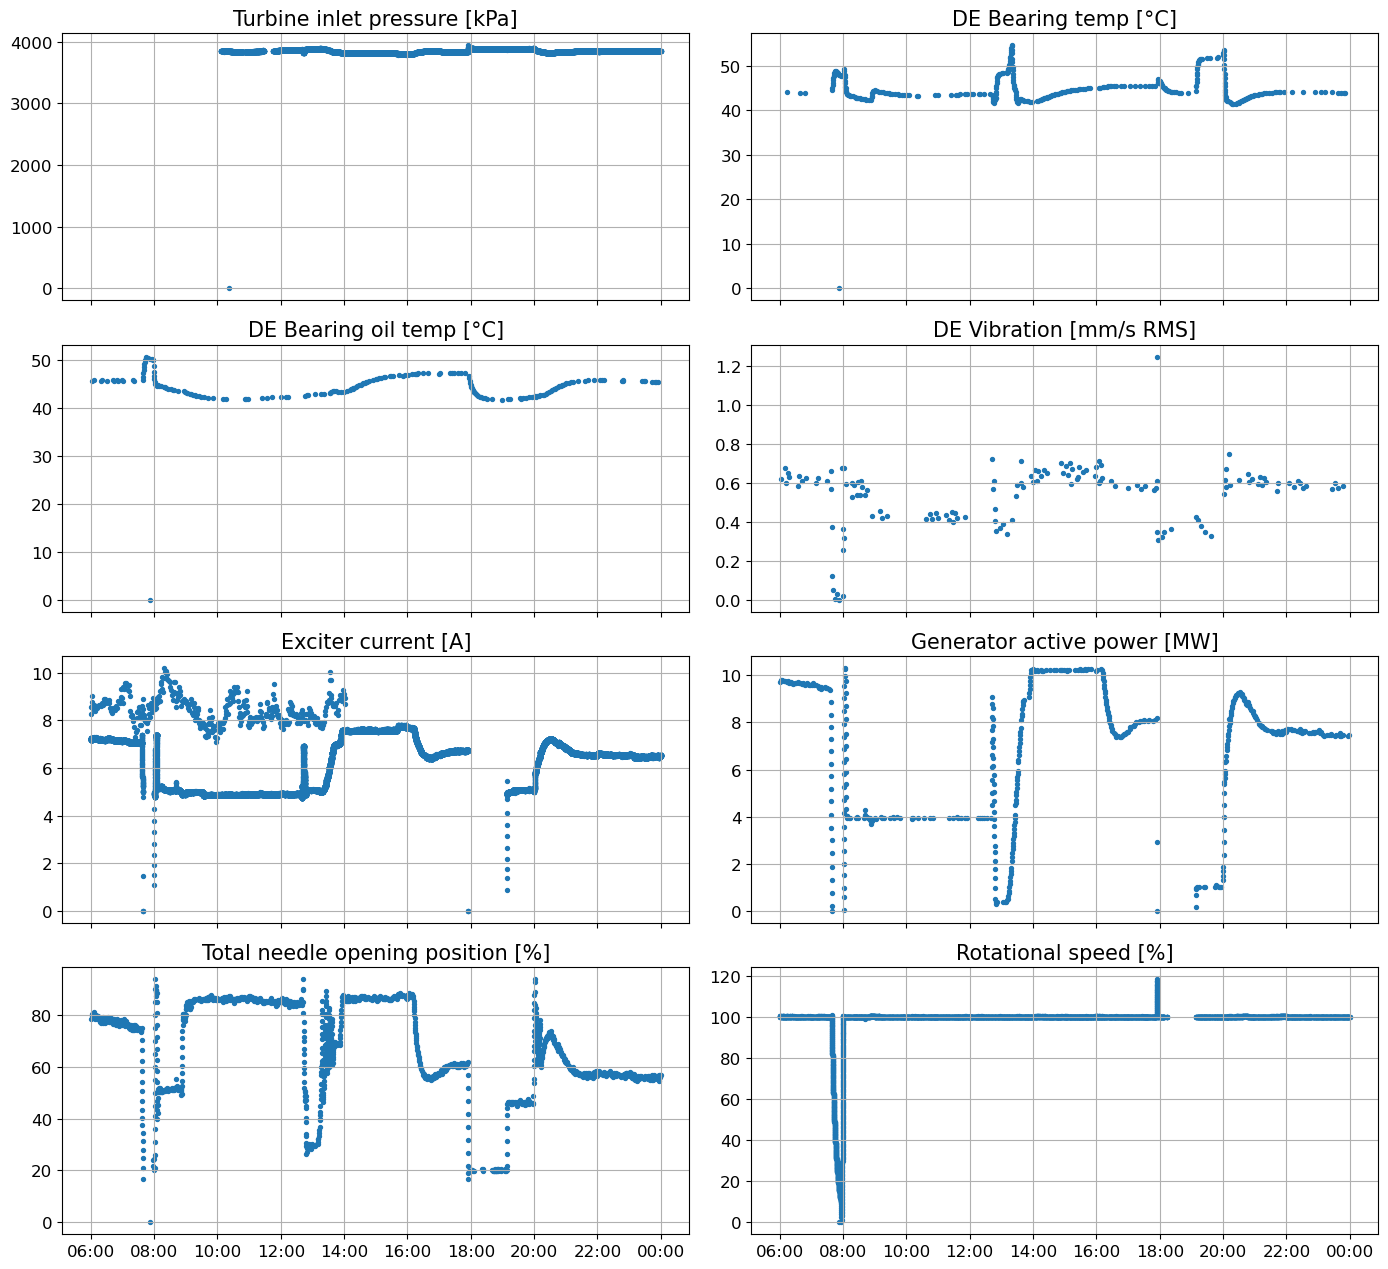

In [4]:
start_time = pd.Timestamp("2024-06-03 06:00:00")
end_time = start_time + pd.Timedelta(hours=18)

n_cols = 2
n_rows = math.ceil(len(dfs_raw) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 3.2 * n_rows),
    sharex=True
)

axes = axes.flatten()

for ax, (_, row) in zip(axes, dfs_raw.iterrows()):
    df_plot = row["signal_df"][
        row["signal_df"]["Datetime"].between(start_time, end_time)
    ]

    name = row["name"]
    unit = row["unit"]

    title = f"{name} [{unit}]" if pd.notna(unit) else name

    ax.scatter(df_plot["Datetime"], df_plot["signal"], s=8)
    ax.set_title(title, fontsize=15)
    ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(True)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

for ax in axes[len(dfs_raw):]:
    ax.remove()

plt.tight_layout()
plt.savefig("figures/raw_signal_scatter_plot.png", dpi=300, bbox_inches="tight")
plt.show()